In [1]:
import torch
import torch.nn as nn 
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def create_complex_dataset(n_samples = 1200):
    X = torch.randn(n_samples,20)  # (1200,20)
    # 비선형  및 노이즈 추가
    y = (torch.sin(X[:, 0] * 2) + X[:, 1]**2 - torch.abs(X[:, 2]) + torch.randn(n_samples) * 0.1).reshape(-1, 1)
    # 정규화
    y = (y - y.mean()) / y.std()
    return TensorDataset(X,y)
dataset = create_complex_dataset()
train_size = int(0.8*len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset =  random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [3]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path = 'best_model.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = float('inf')
        self.eary_stop = False
        self.counter = 0
    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)            
        else:
            self.counter += 1            
            if self.counter >= self.patience:
                self.eary_stop = True       
earlystopping = EarlyStopping()

In [4]:
class AdvancedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(20,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32,1)
        )
    def forward(self, x):
        return self.network(x)

model = AdvancedModel() 

In [5]:
from tqdm import tqdm
epochs = 300
lr = 0.001
optimizer = optim.Adam(model.parameters() ,lr=lr)
criterion = nn.MSELoss()

train_losses = []; val_losses = []

pbar = tqdm(range(epochs))
for epoch in pbar:
    model.train()
    t_loss= 0
    for x, y in train_loader:
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        t_loss +=loss.item()
    
    v_loss = 0
    model.eval()    
    with torch.no_grad():
        for vx, vy in val_loader:
            v_loss += criterion(model(vx),vy).item()
    avg_train = t_loss / len(train_loader)
    avg_val = v_loss / len(val_loader)
    train_losses.append(avg_train); val_losses.append(avg_val)

    pbar.set_postfix({'t-loss': f'{avg_train:.4f}' , 'val-loss' : f'{avg_val:.4f}'  })
    earlystopping(avg_val,model)
    if earlystopping.eary_stop:
        break


 19%|█▉        | 57/300 [00:06<00:26,  9.27it/s, t-loss=0.4058, val-loss=0.2991]


ValueError: x and y must have same first dimension, but have shapes (300,) and (1,)

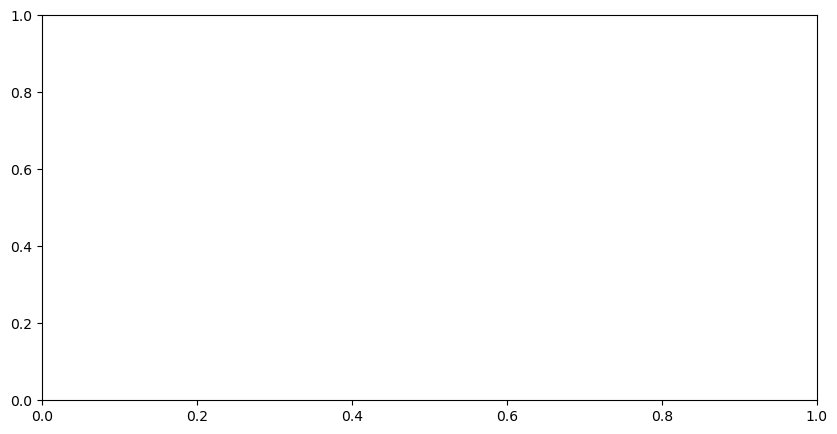

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(range(epochs), t_loss, label='train_loss')
plt.plot(range(epochs), v_loss, label='val_loss')
plt.legend()
plt.show()